In [1]:
import r2l
import gymnasium as gym
import torch
import rl_utils
import matplotlib.pyplot as plt

/home/austin/.conda/envs/r2l/lib/python3.12/site-packages/gymnasium/envs/registration.py:519: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(
Iteration 0:   0%|          | 0/50 [00:00<?, ?it/s]/home/austin/workspace/d2l/src/r2l.py:1163: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  states = torch.tensor(transition_dict["states"], dtype=torch.float).to(
Iteration 9: 100%|██████████| 50/50 [00:01<00:00, 25.03it/s, episode=500, return=170.300]


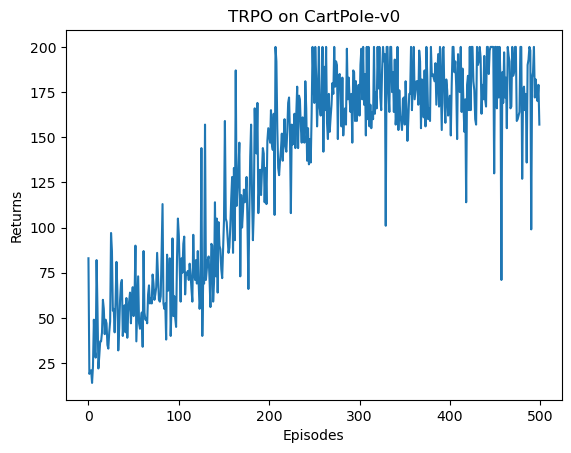

In [2]:
num_episodes = 500
hidden_dim = 128
gamma = 0.98
lmbda = 0.95
critic_lr = 1e-2
kl_constraint = 0.0005
alpha = 0.5
device = r2l.get_gpu()

env_name = 'CartPole-v0'
env = gym.make(env_name)
env.reset(seed=0)
torch.manual_seed(1)
agent = r2l.TRPO(hidden_dim, env.observation_space, env.action_space,lmbda,kl_constraint,alpha,critic_lr, gamma, device)
return_list = rl_utils.train_on_policy_agent(env, agent, num_episodes)

episodes_list= list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('TRPO on {}'.format(env_name))
plt.show()

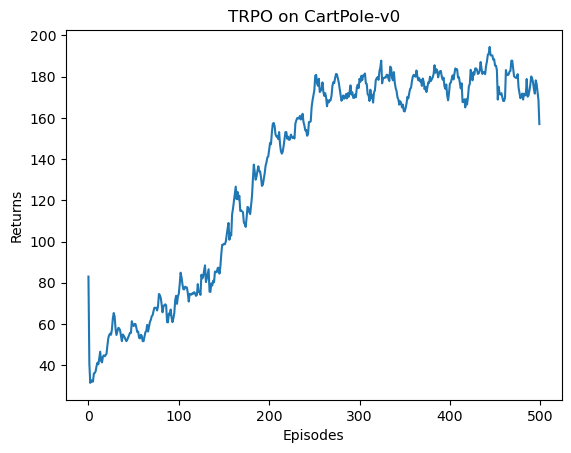

In [3]:
mv_return  = rl_utils.moving_average(return_list, 9)
plt.plot(episodes_list, mv_return)
plt.xlabel("Episodes")
plt.ylabel("Returns")
plt.title("TRPO on {}".format(env_name))
plt.show()

In [ ]:
# TRPO 连续动作空间

In [2]:
num_episodes = 2000
hidden_dim = 128 
gamma = 0.9
lmbda = 0.9
critic_lr = 1e-2
kl_constraint = 0.00005
alpha = 0.5
device  = r2l.get_gpu()


In [3]:
env_name = 'Pendulum-v1'
env = gym.make(env_name)
env.reset(seed=0)
torch.manual_seed(0)
agent = r2l.TRPOContinuous(hidden_dim, env.observation_space, env.action_space, lmbda, kl_constraint, alpha, critic_lr, gamma, device)
return_list = rl_utils.train_on_policy_agent(env, agent, num_episodes)


Iteration 0:   0%|          | 0/200 [00:00<?, ?it/s]/home/austin/workspace/d2l/src/r2l.py:1359: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  states = torch.tensor(transition_dict["states"], dtype=torch.float).to(
Iteration 9: 100%|██████████| 200/200 [00:04<00:00, 42.57it/s, episode=2000, return=-435.180]


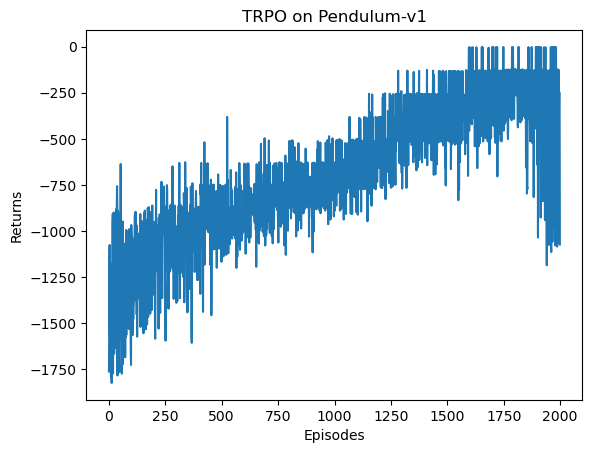

In [4]:
episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('TRPO on {}'.format(env_name))
plt.show()

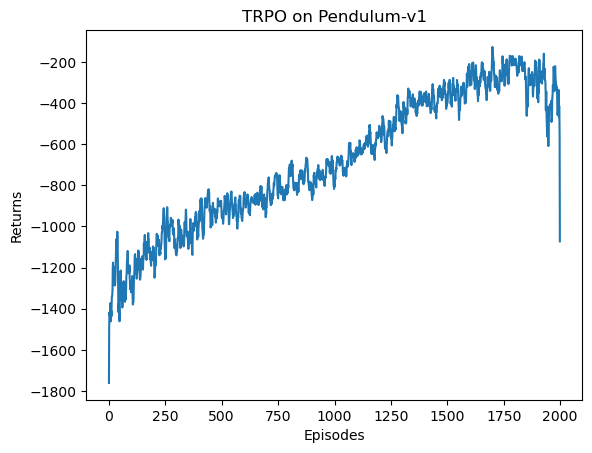

In [5]:
moving_return = rl_utils.moving_average(return_list, 9)
plt.plot(episodes_list, moving_return)
plt.xlabel("Episodes")
plt.ylabel("Returns")
plt.title("TRPO on {}".format(env_name))
plt.show()